# Fase 7 — eICU Vitales (primera medición 0–60 min)

Extrae la primera medición de cada constante vital disponible en los primeros 60 minutos desde el ingreso a UCI (offset=0), equivalente al snapshot de triage en MIMIC-IV-ED.

**Estrategia de extracción:**
- `vitalPeriodic.csv` (7,9 GB): lectura en chunks de 500k filas, filtro offset 0–60 min.
- `vitalAperiodic.csv`: tensión arterial no invasiva como fallback para SBP/DBP.
- `admissionDrug.csv`: conteo de fármacos como proxy de `n_medications`.

La lectura en chunks es necesaria por el tamaño del fichero; se filtra por `patientunitstayid` de la cohorte para reducir la memoria. Este notebook tarda aproximadamente 10 minutos.

In [1]:
import logging, sys
from pathlib import Path

_root = Path.cwd()
while not (_root / 'CLAUDE.md').exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

logging.basicConfig(level=logging.INFO, format='%(levelname)s — %(message)s', force=True)
print(f'Raíz del proyecto: {_root}')

Raíz del proyecto: C:\Users\cuent\Documents\UAX\TFM\TFM


In [2]:
import numpy as np
import pandas as pd

EICU = _root / 'data/eicu-collaborative-research-database-2.0'
OUT  = _root / 'data/processed'

cohort   = pd.read_parquet(OUT / 'eicu_cohort.parquet')
stay_ids = set(cohort['patientunitstayid'].values)
print(f'Cohorte cargada: {len(stay_ids):,} estancias')

Cohorte cargada: 89,594 estancias


## 1. vitalPeriodic — lectura en chunks (7.9 GB)

In [3]:
VP_VITALS = ['temperature', 'heartrate', 'respiration', 'sao2',
             'systemicsystolic', 'systemicdiastolic']

chunks = []
total_read = 0
for i, chunk in enumerate(pd.read_csv(
        EICU / 'vitalPeriodic.csv',
        chunksize=500_000,
        usecols=['patientunitstayid', 'observationoffset'] + VP_VITALS)):
    total_read += len(chunk)
    chunk = chunk[chunk['patientunitstayid'].isin(stay_ids)]
    chunk = chunk[(chunk['observationoffset'] >= 0) & (chunk['observationoffset'] <= 60)]
    if len(chunk):
        chunks.append(chunk)
    if (i + 1) % 10 == 0:
        print(f'  Chunk {i+1}: {total_read/1e6:.0f}M filas leídas, {sum(len(c) for c in chunks):,} filtradas')

vp = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()
print(f'\nTotal filtrado: {len(vp):,} filas para {vp["patientunitstayid"].nunique():,} pacientes')

  Chunk 10: 5M filas leídas, 25,815 filtradas
  Chunk 20: 10M filas leídas, 51,784 filtradas
  Chunk 30: 15M filas leídas, 74,281 filtradas
  Chunk 40: 20M filas leídas, 104,850 filtradas
  Chunk 50: 25M filas leídas, 137,843 filtradas
  Chunk 60: 30M filas leídas, 168,857 filtradas
  Chunk 70: 35M filas leídas, 200,331 filtradas
  Chunk 80: 40M filas leídas, 232,609 filtradas
  Chunk 90: 45M filas leídas, 252,677 filtradas
  Chunk 100: 50M filas leídas, 271,278 filtradas
  Chunk 110: 55M filas leídas, 304,718 filtradas
  Chunk 120: 60M filas leídas, 331,056 filtradas
  Chunk 130: 65M filas leídas, 360,195 filtradas
  Chunk 140: 70M filas leídas, 377,855 filtradas
  Chunk 150: 75M filas leídas, 400,478 filtradas
  Chunk 160: 80M filas leídas, 438,623 filtradas
  Chunk 170: 85M filas leídas, 480,256 filtradas
  Chunk 180: 90M filas leídas, 507,621 filtradas
  Chunk 190: 95M filas leídas, 536,955 filtradas
  Chunk 200: 100M filas leídas, 570,925 filtradas
  Chunk 210: 105M filas leídas, 

In [4]:
vp = vp.sort_values('observationoffset')
vp_agg = vp.groupby('patientunitstayid')[VP_VITALS].first().reset_index()
print(f'Agregado: {len(vp_agg):,} pacientes con al menos una medicion')

Agregado: 79,532 pacientes con al menos una medicion


## 2. vitalAperiodic — BP no invasiva (fallback)

Tensión arterial no invasiva de `vitalAperiodic.csv`. Se usa como fuente de SBP/DBP únicamente cuando la medición invasiva (`systemicsystolic`/`systemicdiastolic`) es nula, para maximizar la cobertura de datos.

In [5]:
va_chunks = []
for chunk in pd.read_csv(
        EICU / 'vitalAperiodic.csv',
        chunksize=500_000,
        usecols=['patientunitstayid', 'observationoffset',
                 'noninvasivesystolic', 'noninvasivediastolic']):
    chunk = chunk[chunk['patientunitstayid'].isin(stay_ids)]
    chunk = chunk[(chunk['observationoffset'] >= 0) & (chunk['observationoffset'] <= 60)]
    if len(chunk):
        va_chunks.append(chunk)

va = pd.concat(va_chunks, ignore_index=True) if va_chunks else pd.DataFrame()
va = va.sort_values('observationoffset')
va_agg = (va.groupby('patientunitstayid')[['noninvasivesystolic', 'noninvasivediastolic']]
            .first().reset_index())
print(f'BP no invasiva: {len(va_agg):,} pacientes')

BP no invasiva: 74,146 pacientes


## 3. Merge y construcción del DataFrame de vitales

Fusión de mediciones periódicas e aperiódicas con prioridad a la medición invasiva (SBP/DBP sistémica) sobre el fallback no invasivo. Se renombran columnas para alinear la nomenclatura con la de MIMIC-IV-ED.

In [6]:
vitals = vp_agg.merge(va_agg, on='patientunitstayid', how='left')

# Se renombran columnas para alinear con la nomenclatura de MIMIC-IV-ED
vitals = vitals.rename(columns={'respiration': 'resprate', 'sao2': 'o2sat'})

# SBP/DBP: se usa la medición invasiva si existe; si no, fallback a no invasiva
vitals['sbp'] = vitals['systemicsystolic'].fillna(vitals['noninvasivesystolic'])
vitals['dbp'] = vitals['systemicdiastolic'].fillna(vitals['noninvasivediastolic'])

keep = ['patientunitstayid', 'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']
vitals = vitals[keep]
print(f'Vitales shape: {vitals.shape}')

Vitales shape: (79532, 7)


## 4. n_medications desde admissionDrug

Recuento de fármacos al ingreso como proxy de polimedicación/multimorbilidad. Es la variable equivalente a `n_medications` de MIMIC-IV-ED y se necesita para que el vector de features sea homogéneo entre cohortes.

In [7]:
adm = pd.read_csv(EICU / 'admissionDrug.csv',
                  usecols=['patientunitstayid', 'drugname'])
adm = adm[adm['patientunitstayid'].isin(stay_ids)]
nmeds = (adm.groupby('patientunitstayid')['drugname']
            .count()
            .reset_index()
            .rename(columns={'drugname': 'n_medications'}))

vitals = vitals.merge(nmeds, on='patientunitstayid', how='left')
vitals['n_medications'] = vitals['n_medications'].fillna(0)
print(f'n_medications media: {vitals["n_medications"].mean():.1f}')

n_medications media: 5.3


## 5. Análisis de valores faltantes

Fracción de valores ausentes por feature en el subconjunto de vitales 0–60 min. La temperatura presenta alta tasa de missing (~95%) porque la mayoría de sensores periódicos registran primero FC y SpO₂; se imputa en el notebook de inferencia.

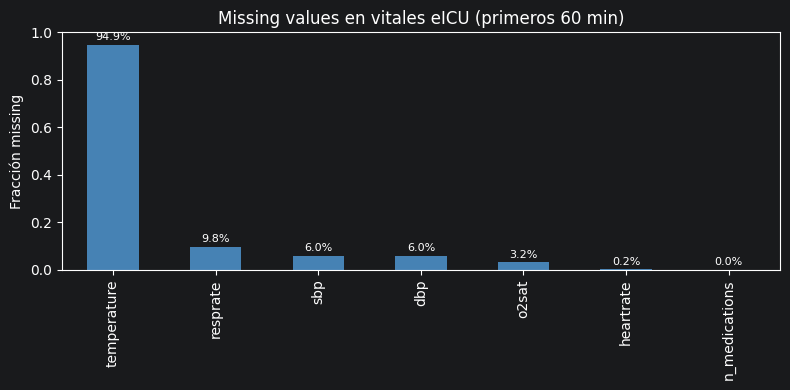

Pacientes sin ningún vital en 0–60 min: 10,062 (se imputan con mediana MIMIC)


In [8]:
import matplotlib.pyplot as plt

feat_cols = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'n_medications']
missing = vitals[feat_cols].isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
missing.plot(kind='bar', ax=ax, color='steelblue')
ax.set_ylabel('Fracción missing')
ax.set_title('Missing values en vitales eICU (primeros 60 min)')
ax.set_ylim(0, 1)
for bar, val in zip(ax.patches, missing):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

n_no_vital = len(stay_ids) - vitals['patientunitstayid'].nunique()
print(f'Pacientes sin ningún vital en 0–60 min: {n_no_vital:,} (se imputan con mediana MIMIC)')

## 6. Guardar

Se serializa el DataFrame de vitales en `data/processed/eicu_vitals.parquet`. Los valores ausentes no se imputan en este paso; la imputación se realiza en el notebook de inferencia con las medianas del set de entrenamiento MIMIC.

In [9]:
vitals.to_parquet(OUT / 'eicu_vitals.parquet', index=False)
print(f'Guardado: eicu_vitals.parquet — shape {vitals.shape}')
vitals.describe().round(2)

Guardado: eicu_vitals.parquet — shape (79532, 8)


,patientunitstayid,temperature,heartrate,resprate,o2sat,sbp,dbp,n_medications
count,79532.00,4095.00,79411.00,71766.00,76964.00,74762.00,74765.00,79532.00
mean,1751206.53,37.30,89.64,20.74,96.56,125.80,70.36,5.33
std,979763.86,8.67,21.43,7.18,5.41,29.39,19.88,38.47
min,141178.00,0.00,0.00,0.00,0.00,-40.00,-41.00,0.00
25%,961556.50,35.60,74.00,16.00,95.00,106.00,57.00,0.00
50%,1705813.50,36.70,88.00,20.00,98.00,123.00,68.00,0.00
75%,2727179.50,37.60,103.00,24.00,100.00,144.00,81.00,0.00
max,3353263.00,105.60,218.00,176.00,100.00,356.00,349.00,6168.00
